# Module 15: Gradient Descent and Optimization

## Learning Outcomes
- • Compute the approximate value of a function using its derivative.
- • Identify the basics of gradient descent and the impact of learning rate on convergence.
- • Compute x and/or y for each iteration of gradient descent.
- • Optimize a single-parameter linear regression model from scratch.
- • Recognize convex one-dimensional and two-dimensional functions.
- • Compute the gradient of a two-dimensional function.
- • Measure the impurity of a decision tree using entropy.
- • Use gradient descent to optimize a nonlinear two-dimensional regression model.
- • Use stochastic gradient descent to optimize a nonlinear two-dimensional regression model.
- • Compare the convergence behavior of gradient descent with stochastic gradient descent.
- • Articulate the impact of stochastic gradient on bias and variance.

## Key Activities
- • Videos 15.1–15.15
- • Required Knowledge Checks 15.1–15.6
- • Required Codio Assignments 15.1–15.4
- • Self-Study Colab Activities 15.1–15.4

## Notes

## Example Code

## Summary



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px

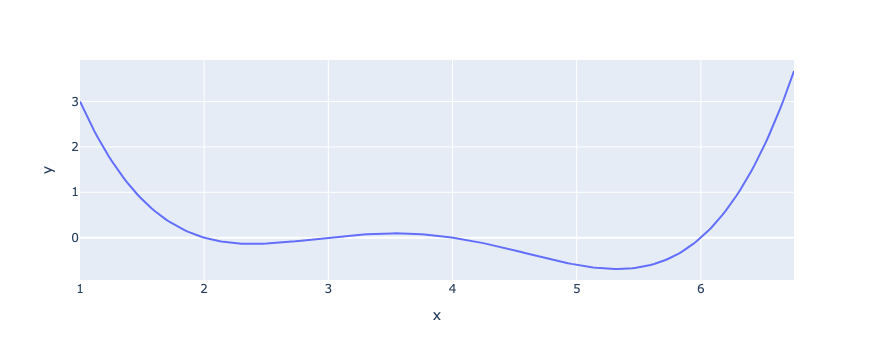

In [2]:
def arbitrary(x):
    return (x**4 - 15*x**3 + 80*x**2 - 180*x + 144)/10

x = np.linspace(1, 6.75, 200)
px.line(y = arbitrary(x), x=x)

In [3]:
from scipy.optimize import minimize

minimize(arbitrary, x0 = 6)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.6914096788729693
        x: [ 5.326e+00]
      nit: 7
      jac: [-3.055e-06]
 hess_inv: [[ 4.747e-01]]
     nfev: 16
     njev: 8

In [4]:
minimize(arbitrary, x0 = 1)


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.13827491294422317
        x: [ 2.393e+00]
      nit: 7
      jac: [-3.800e-07]
 hess_inv: [[ 7.475e-01]]
     nfev: 16
     njev: 8

In [5]:
arbitrary(5.3)

-0.690689999999995

In [10]:
def simple_minimize(f, xs):
    y = [f(x) for x in xs]
    return xs[np.argmin(y)]

In [11]:
np.linspace(1,7,20)

array([1.        , 1.31578947, 1.63157895, 1.94736842, 2.26315789,
       2.57894737, 2.89473684, 3.21052632, 3.52631579, 3.84210526,
       4.15789474, 4.47368421, 4.78947368, 5.10526316, 5.42105263,
       5.73684211, 6.05263158, 6.36842105, 6.68421053, 7.        ])

In [12]:
simple_minimize(arbitrary, np.linspace(1,7,20))

np.float64(5.421052631578947)

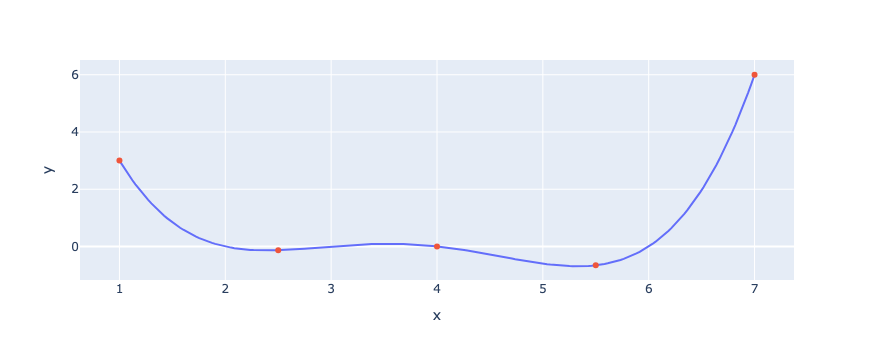

In [18]:
xs = np.linspace(1, 7, 200)
sparse_xs = np.linspace(1, 7, 5)

ys = arbitrary(xs)
sparse_ys = arbitrary(sparse_xs)

fig = px.line(x = xs, y = arbitrary(xs))
fig.add_scatter(x = sparse_xs, y = arbitrary(sparse_xs), mode = 'markers')
fig.update_layout(showlegend= False)
fig.show()

In [20]:
import plotly.graph_objects as go

def derivative_arbitrary(x):
    return (4*x**3 - 45*x**2 + 160*x - 180)/10

def line(x):
    return (0*x)

fig = go.Figure()
fig.add_trace(go.Scatter(x = xs, y = arbitrary(xs), mode = 'lines', name = 'f'))
fig.add_trace(go.Scatter(x = xs, y = derivative_arbitrary(xs), mode = 'lines', name = 'df', line= {'dash': 'dash'}))
fig.add_trace(go.Scatter(x = xs, y = line(xs), mode = 'lines', name = 'zero'))
fig.update_layout(font_size = 20, yaxis_range=[-1, 3])
fig.show

<bound method BaseFigure.show of Figure({
    'data': [{'mode': 'lines',
              'name': 'f',
              'type': 'scatter',
              'x': {'bdata': ('AAAAAAAA8D/iMFZbf3vwP8VhrLb+9v' ... 'JAwhtAx3MqKSDhG0AAAAAAAAAcQA=='),
                    'dtype': 'f8'},
              'y': {'bdata': ('AAAAAAAACECmvkuD544GQDr+yAS1LA' ... 'D3gBVAAMZ2nBm7FkAAAAAAAAAYQA=='),
                    'dtype': 'f8'}},
             {'line': {'dash': 'dash'},
              'mode': 'lines',
              'name': 'df',
              'type': 'scatter',
              'x': {'bdata': ('AAAAAAAA8D/iMFZbf3vwP8VhrLb+9v' ... 'JAwhtAx3MqKSDhG0AAAAAAAAAcQA=='),
                    'dtype': 'f8'},
              'y': {'bdata': ('ZmZmZmZmGMB4Mul0SmwXwDZo5RdCeB' ... 'RMASRAc12CAg2yJEBmZmZmZmYlQA=='),
                    'dtype': 'f8'}},
             {'mode': 'lines',
              'name': 'zero',
              'type': 'scatter',
              'x': {'bdata': ('AAAAAAAA8D/iMFZbf3vwP8VhrLb+9v' ... 'JAwhtAx3MqKSDhG0AAA

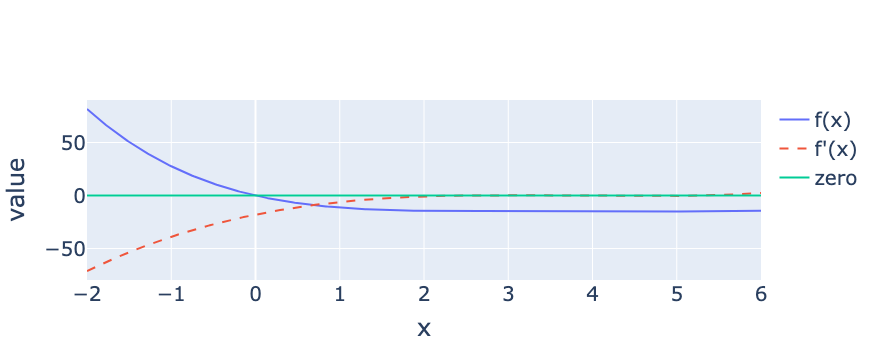

In [21]:
import numpy as np
import plotly.graph_objects as go

xs = np.linspace(-2, 6, 500)

def arbitrary(x):
    return (x**4 - 15*x**3 + 80*x**2 - 180*x) / 10

def derivative_arbitrary(x):
    return (4*x**3 - 45*x**2 + 160*x - 180) / 10

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=xs, y=arbitrary(xs),
    mode='lines', name='f(x)'
))

fig.add_trace(go.Scatter(
    x=xs, y=derivative_arbitrary(xs),
    mode='lines', name="f'(x)",
    line={'dash': 'dash'}
))

fig.add_trace(go.Scatter(
    x=xs, y=np.zeros_like(xs),
    mode='lines', name='zero'
))

fig.update_layout(
    font_size=20,
    xaxis_title="x",
    yaxis_title="value"
)

fig.show()

In [22]:
import matplotlib.pyplot as plt

def plot_arbitrary():
    x = np.linspace(1, 7, 100)
    plt.plot(x, arbitrary(x))
    axes = plt.gca()
    axes.set_ylim([-1, 3])

def plot_x_on_f(f, x):
    y = f(x)
    default_args = dict(label=r'$ \theta $', zorder=2, s=200, c=sns.xkcd_rgb['green'])
    plt.scatter([x], [y], **default_args)

def plot_x_on_f_empty(f, x):
    y = f(x)
    default_args = dict(label=r'$ \theta $', zorder=2, s=200, c='none', edgecolor=sns.xkcd_rgb['green'])
    plt.scatter([x], [y], **default_args)

def plot_tangent_on_f(f, x, eps=1e-6):
    slope = ((f(x + eps) - f(x-eps)) / (2*eps))
    xs = np.arange(x -1, x+1, 0.050)
    ys = f(x) + slope * (xs - x)
    plt.plot(xs, ys, zorder=3, c=sns.xkcd_rgb['green'], linestyle='--')

Text(0.5, 0, 'x')

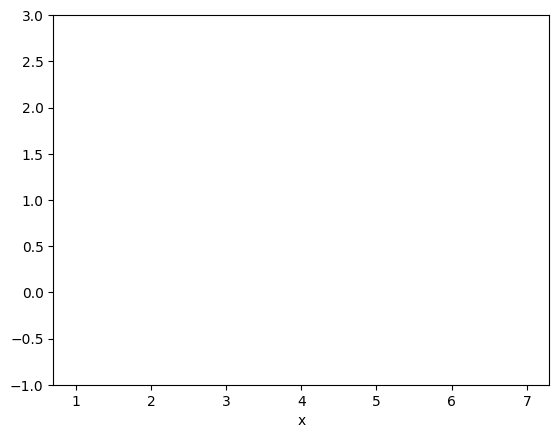

In [23]:
plot_arbitrary()
plot_x_on_f(arbitrary, 3)
plot_tangent_on_f(arbitrary, 3)
plt.xlabel('x')

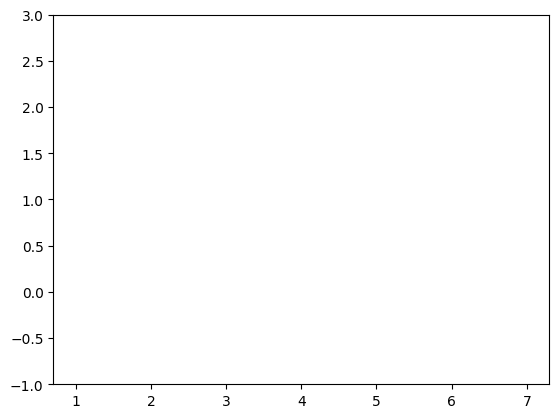

In [24]:
plot_arbitrary()
plot_x_on_f(arbitrary, 6)
plot_tangent_on_f(arbitrary, 6)

In [31]:
import numpy as np

def batch_gradient_descent(x, y_actual, w_init=0.5, lr=0.01, epochs=10):
    w = w_init
    mse_history = []
    w_history = [w_init]

    for epoch in range(epochs):
        y_hat = w * x
        gradient = -2 * np.mean(x * (y_actual - y_hat))
        w = w - lr * gradient
        w_history.append(w)
        mse = np.mean((y_actual - y_hat) ** 2)
        mse_history.append(mse)

    return w, mse_history, w_history

x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y_actual = np.array([0.0, 0.8, 2.2, 2.3, 4.3, 4.9], dtype=float)

w, mse_history, w_history = batch_gradient_descent(x, y_actual)

print("Final w:", w)
print("MSE history:", mse_history)

Final w: 0.9150800751924155
MSE history: [np.float64(2.2033333333333336), np.float64(1.5052387962962965), np.float64(1.0396485231224282), np.float64(0.7291256770417455), np.float64(0.5220241899751569), np.float64(0.38389900373991276), np.float64(0.2917771781424621), np.float64(0.23033703834816252), np.float64(0.1893598784464642), np.float64(0.16203038930091498)]


In [32]:
import numpy as np

def stochastic_gradient_descent(x, y_actual, w_init=0.2, lr=0.01, epochs=10):
    w = w_init
    mse_history = []
    w_history = [w_init]
    n = len(x)

    for epoch in range(epochs):
        # Shuffle indices each epoch (recommended)
        indices = np.random.permutation(n)

        for i in indices:
            # Prediction for a single data point
            y_hat = w * x[i]

            # Gradient of MSE loss w.r.t. w for one point
            gradient = -2 * x[i] * (y_actual[i] - y_hat)

            # Update weight
            w = w - lr * gradient

            # Track history
            w_history.append(w)
            mse = (y_actual[i] - y_hat) ** 2
            mse_history.append(mse)

    return w, mse_history, w_history

In [33]:
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y_actual = np.array([0.0, 0.8, 2.2, 2.3, 4.3, 4.9], dtype=float)

w, mse_history, w_history = stochastic_gradient_descent(
    x, y_actual, w_init=0.2, lr=0.01, epochs=10
)

print("Final w:", w)

Final w: 0.9889374295025992


In [34]:
import numpy as np

def mini_batch_gradient_descent(
    x, y_actual, w_init=0.5, lr=0.01, epochs=10, batch_size=2
):
    w = w_init
    mse_history = []
    w_history = [w_init]
    n = len(x)

    for epoch in range(epochs):
        # Shuffle data each epoch
        indices = np.arange(n)
        np.random.shuffle(indices)
        x_shuffled = x[indices]
        y_shuffled = y_actual[indices]

        # Process mini-batches
        for i in range(0, n, batch_size):
            x_batch = x_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]

            # Prediction for mini-batch
            y_hat = w * x_batch

            # Gradient of MSE loss for mini-batch
            gradient = -2 * np.mean(x_batch * (y_batch - y_hat))

            # Update weight
            w = w - lr * gradient

            # Track history
            w_history.append(w)
            mse = np.mean((y_batch - y_hat) ** 2)
            mse_history.append(mse)

    return w, mse_history, w_history

In [35]:
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y_actual = np.array([0.0, 0.8, 2.2, 2.3, 4.3, 4.9], dtype=float)

w, mse_history, w_history = mini_batch_gradient_descent(
    x,
    y_actual,
    w_init=0.5,
    lr=0.01,
    epochs=10,
    batch_size=2
)

print("Final w:", w)

Final w: 0.9697143961165834
